## Overview

The purpose of this notebook is to provide a standardised testing ground for different algorithms on a perfect inductive curve

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

### Simulated Curve

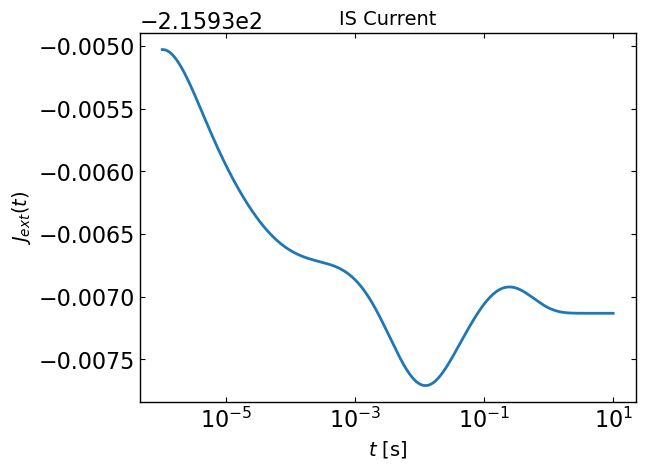

In [3]:
# Path to data
path = '../DRT IS Inductive Behaviour in Spectrum/tj.dat'

# Load Data
data = pd.read_csv(path, sep=r'\s+')

# Find where in the current density curve we see decay lifetimes 
start_index = 155
end_index = -1 #870
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values

# Plot the Current Density
plt.plot(time, current)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.show()

In [11]:
# Calculate the number of decades and points per decade (ppd) in the time array
time_decades = np.log10(time[-1]/time[0])
time_ppd = int(len(time) / time_decades)

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
tau_min = (time[1]-time[0])/np.pi   # Selected based on Nyquist spacing
tau_max = time[-1]/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(tau_max/tau_min))
tau_values = np.geomspace(tau_min, tau_max, tau_dec*time_ppd)

# Apply min-max scaling to the data 
current_scaled = (current - current.min())/(current.max() - current.min())

### Algorithms


#### PyTorch Checkerboard

In [12]:
pytorch_checkerboard = drt.checkerboard_fit(time, current_scaled, tau_values, max_fit_iter=100, checkerboard_iter=100)

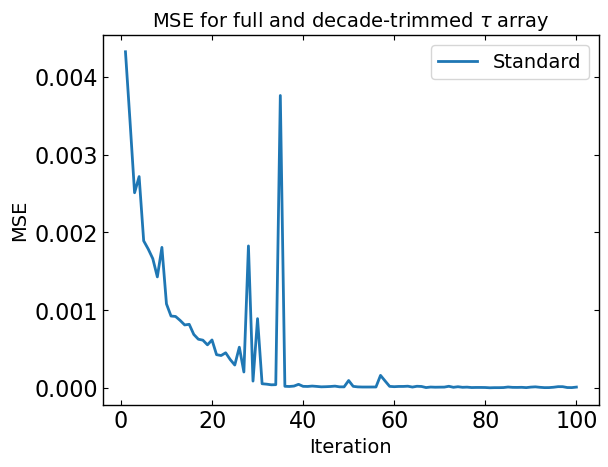

In [13]:
# pytorch MSE
torch_MSE = [np.mean((fit.y - current_scaled)**2) for fit in pytorch_checkerboard]

plt.plot(range(1, len(pytorch_checkerboard)+1), torch_MSE, label='Standard')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

In [14]:
torch_min_fit = pytorch_checkerboard[np.argmin(torch_MSE)]

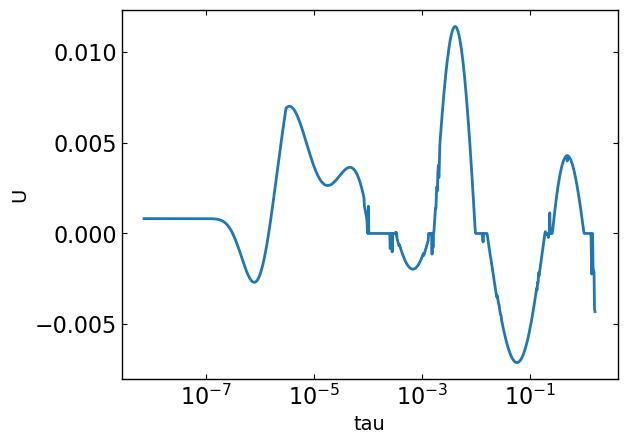

In [15]:
# Plot fitted curves 
plt.plot(tau_values, torch_min_fit.U)
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')

#### OSQP Checkerboard 

In [16]:
osqp_checkerboard = drt.osqp_checkerboard_fit(time, current_scaled, tau_values, checkerboard_iters=100)

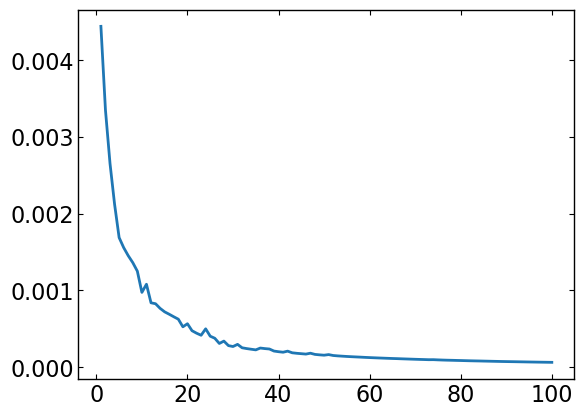

In [17]:
MSE_values_osqp = [fit.cost for fit in osqp_checkerboard]
plt.plot(range(1, len(MSE_values_osqp)+1), MSE_values_osqp)

In [18]:
osqp_checkerboard_min = osqp_checkerboard[np.argmin(MSE_values_osqp)]

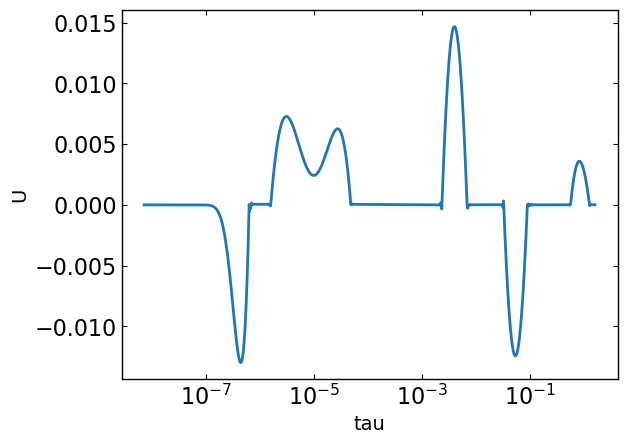

In [23]:
plt.plot(tau_values, osqp_checkerboard_min.U)
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')

#### OSQP Un-Bounded Linear Fit

In [24]:
# Try osqp cap fit for a single bounded iteration
single_osqp_fit = drt.osqp_linear_fit(time, current_scaled + 2, tau_values)

In [25]:
# Calculate scaling constants
y_inf = current[-1]
y_translated = current - y_inf
y_translated_max = np.max(y_translated)
y_translated_min = np.min(y_translated)
R = y_translated_max - y_translated_min

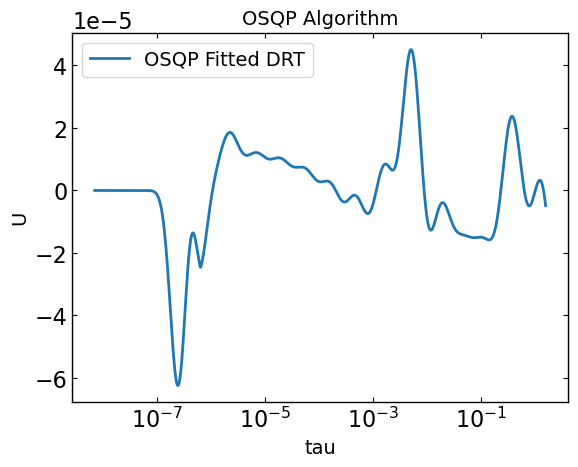

In [26]:
# Plot fitted curves 
plt.plot(tau_values, R*single_osqp_fit.U, label='OSQP Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("OSQP Algorithm")
plt.legend()
plt.show()

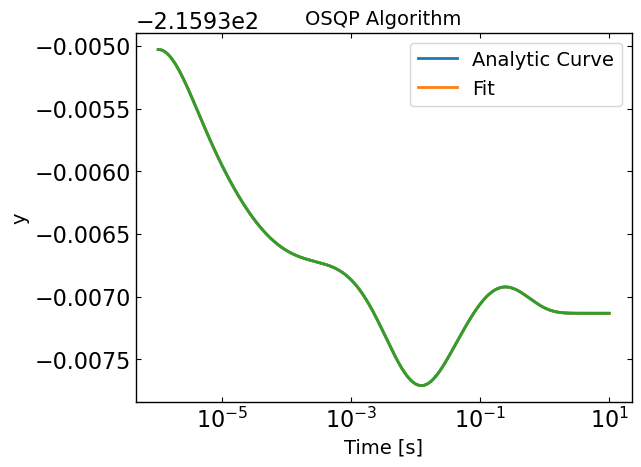

In [27]:
# Plot the two curves against each other
plt.plot(time, current, label='Analytic Curve')
plt.plot(time, drt.predict_y(time, R*single_osqp_fit.U, tau_values, y_inf), label='Fit')
plt.plot(time, drt.predict_y(time, R*single_osqp_fit.U, tau_values, y_inf))
plt.xlabel('Time [s]')
plt.ylabel('y')
plt.title('OSQP Algorithm')
plt.xscale('log')
plt.legend()
plt.show()